# GFP tuned — Fixed Architecture, Data-Tuned GFP Runs (HI-Small)

- **Question:** does the data-tuned GFP sheet `tuned` (64 columns: 48 h windows, simple cycles ≤ 12, bins [2, 4, 6, 8]; `GFP_experiments.ipynb`) beat the paper's V0 sheet (61 columns) when the GNN architecture is held *exactly* fixed?
- **Knobs per run:** `operator` (gin / gat / pna / transformer), `mp` / `readout` edge features as in the operator notebooks, `gfp_variant = 'tuned'`. The swap happens at load time (`gnn_core.load_graphs`): the graph files stay as they are, `edge_attr` becomes 20 baseline + 64 tuned = 84 columns; only the edge projections and the readout's first Linear widen (337 → 340 inputs), nothing else changes. `NODE_ENC` stays `none` — one factor at a time.
- **Everything shared** (model template, training loop, threshold selection, metrics, plots, saving) lives in `gnn_core.py`; this notebook only sets the run list and paths. All eight runs in one session, so the executed notebook holds every training log; each run is compared with the same configuration on V0 in that operator's notebook, on validation F1 (gap < 0.02 = tie).
- **Protocol:** threshold swept on validation each epoch, best-val-F1 checkpoint, test scored once; every metric on train / val / test. `invariant_params` must stay at the family value (GIN 67,587 · GATv2 67,585 · PNA 427,265 · Transformer 133,121).

## 0. Environment (Kaggle)

- Pinned PyTorch / PyG stack known to work on Kaggle GPU — do not change versions or order.
- Then clone (or pull) the public repo so the committed `gnn_core.py` is the one imported.

In [1]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch_geometric

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 151.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 242.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 162.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 60.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 87.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 101.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import sys

REPO_URL = 'https://github.com/sandrokhizanishvili/gnn_for_fraudulent_patterns.git'
REPO_DIR = '/kaggle/working/gnn_for_fraudulent_patterns'
if os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone {REPO_URL} {REPO_DIR}
!git -C {REPO_DIR} log -1 --oneline
sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/gnn_for_fraudulent_patterns'...
remote: Enumerating objects: 376, done.
remote: Counting objects: 100% (376/376), done.
remote: Compressing objects: 100% (324/324), done.
remote: Total 376 (delta 136), reused 284 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (376/376), 13.01 MiB | 12.56 MiB/s, done.
Resolving deltas: 100% (136/136), done.
4e1c11a (HEAD -> main, origin/main, origin/HEAD) GFP_VARIANT knob in gnn_core.py (tuned sheet normalised like V0, swapped into the GFP block at load time, edge_attr 81 -> 84, invariant_params unchanged); GFP_fixed_architecture.ipynb with the 8 tuned configs; EXPERIMENTS/CLAUDE/README/GFP_experiments and Notion experiments page synced (decision rule, GFP tuned runs block)


## 1. Configuration

- The only cell that differs from the operator notebooks: `CONFIGS` lists `(operator, mp, readout, gfp_variant)` per run; all eight runs are active (configs 5 and 4 of every operator).
- `GFP_VARIANT` is fixed for the whole batch (the sheet is swapped in once, at load time); `GFP_DIR`: the Kaggle dataset `hi-small-gfp-tuned` (`Data/gfp_variants/tuned.npy` + `tuned_cols.json`), added as a second input next to `hi-small-gnn`.
- Runs land in `OUT_BASE/<OPERATOR>/<run>/`, mirroring `Outputs/GFP_TUNED/<FAMILY>/` in the repo (separate from the operator batches in `Outputs/<FAMILY>/`); the batch summary is `batch_summary_gfp_tuned.csv` per family.

In [3]:
# runs of this batch — all eight in one session, so this notebook holds every training log
CONFIGS = [
    dict(operator='gin', mp='base', readout='full', gfp_variant='tuned'),          # GIN-5 + tuned — compare with GIN-5
    dict(operator='gin', mp='full', readout='full', gfp_variant='tuned'),          # GIN-4 + tuned — compare with GIN-4
    dict(operator='gat', mp='base', readout='full', gfp_variant='tuned'),          # GAT-5 + tuned — compare with GAT-5
    dict(operator='gat', mp='full', readout='full', gfp_variant='tuned'),          # GAT-4 + tuned — compare with GAT-4
    dict(operator='pna', mp='base', readout='full', gfp_variant='tuned'),          # PNA-5 + tuned — compare with PNA-5
    dict(operator='pna', mp='full', readout='full', gfp_variant='tuned'),          # PNA-4 + tuned — compare with PNA-4
    dict(operator='transformer', mp='base', readout='full', gfp_variant='tuned'),  # TR-5 + tuned — compare with TR-5
    dict(operator='transformer', mp='full', readout='full', gfp_variant='tuned'),  # TR-4 + tuned — compare with TR-4
]
GFP_VARIANT       = 'tuned'  # 'v0' | 'tuned' — fixed for the whole batch (the sheet is swapped in once, at load time)
MP_DIRECTION      = 'in'     # 'in' | 'bidirectional' — fixed for the whole batch
TEMPORAL_SAMPLING = False    # True samples only edges earlier than the seed (needs pyg-lib)
assert all(cfg['gfp_variant'] == GFP_VARIANT for cfg in CONFIGS), 'one GFP sheet per batch'

# paths
DATA_DIR    = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gnn'
GFP_DIR     = '/kaggle/input/datasets/sandrokhizanishvili/hi-small-gfp-tuned'   # Data/gfp_variants/ as a separate Kaggle dataset
OUT_BASE    = '/kaggle/working/Outputs/GFP_TUNED'                               # runs go to OUT_BASE/<OPERATOR>/, mirrors Outputs/GFP_TUNED/<FAMILY>/

import gnn_core as core
for cfg in CONFIGS:
    os.makedirs(f"{OUT_BASE}/{cfg['operator'].upper()}", exist_ok=True)
print(f'torch {core.torch.__version__} | device {core.device} | gnn_core from {core.__file__}')

torch 2.8.0+cu126 | device cuda | gnn_core from /kaggle/working/gnn_for_fraudulent_patterns/gnn_core.py


## 2. Load graphs

- Three cumulative PyG snapshots; context edges carry label −1, only `eval_mask` edges are scored.
- `GFP_VARIANT = 'tuned'`: `tuned.npy` is normalised exactly like V0 (log1p → clip at train p1 / p99 → StandardScaler, fit on the train rows; pattern bins untouched) and replaces the GFP block of every snapshot, so `edge_attr` becomes 84 wide.
- `col_sets` maps each knob value to `edge_attr` columns: base = first 20, gfp = next 64, full = all 84.

In [4]:
graphs, col_sets, node_dim = core.load_graphs(DATA_DIR, GFP_VARIANT, GFP_DIR)

GFP variant tuned: sheet (5077237, 64) from /kaggle/input/datasets/sandrokhizanishvili/hi-small-gfp-tuned
GFP normalisation: untouched pattern bins 12 | log+scale 40 | scale-only 12 | fit on the first 3,046,342 rows
vertex stats after normalisation: min=-9.58 max=5.56 mean=0.055 std=1.026
edge_attr width 84 (base 20 + gfp 64, variant tuned)
train nodes=515,070 edges=3,046,342 evaluated=3,046,342 laundering=2,297 (0.0754%)
val   nodes=515,070 edges=4,061,789 evaluated=1,015,447 laundering=1,082 (0.1066%)
test  nodes=515,070 edges=5,077,237 evaluated=1,015,448 laundering=1,143 (0.1126%)


## 3. Model

- Fixed template (`gnn_core.EdgeClassifier`): `node_proj` → 2 message-passing layers (hidden 128, dropout 0.3, residual) → readout MLP on `[h_src ‖ h_dst ‖ e_seed]`; only the conv differs between operators.
- Against the V0 run of the same configuration only the readout's first Linear widens (337 → 340 inputs) and, with `mp = full`, the conv's edge projection (81 → 84 inputs); +384 parameters per widened tensor.
- `invariant_params` leaves those tensors out and must print the family value; PNA also needs the training-graph in-degree histogram.

In [5]:
cfg = CONFIGS[0]
deg_hist = core.in_degree_histogram(graphs['train']) if cfg['operator'] == 'pna' else None
model = core.build_model(cfg['operator'], node_dim, len(col_sets[cfg['mp']]), len(col_sets[cfg['readout']]),
                         MP_DIRECTION == 'bidirectional', deg_hist)
print(model)
print(f'readout input {model.classifier[0].in_features} | params {core.count_params(model):,} | '
      f'invariant_params {core.invariant_params(model):,}   (config {cfg})')
del model

EdgeClassifier(
  (node_proj): Linear(in_features=6, out_features=128, bias=True)
  (layers): ModuleList(
    (0-1): 2 x MPLayer(
      (conv_in): GINEConv(nn=Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=128, bias=True)
      ))
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=340, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
readout input 340 | params 116,611 | invariant_params 67,587   (config {'operator': 'gin', 'mp': 'base', 'readout': 'full', 'gfp_variant': 'tuned'})


## 4. Run the batch

- One call per config: seed → model → loaders → 20 epochs → best checkpoint → all splits scored → `results.json`, `history.csv`, `curves.png`, `best.pt`, `predictions.csv` under `OUT_ROOT/<run>/`.
- `predictions.csv`: every evaluated edge of train / val / test with `edge_id` (= row in `Data/edge_features.csv`), `src`, `dst`, `edge_time`, `y`, `prob` (probability) and `pred` (class at the val-chosen threshold) — for the typology / error analyses.
- Per-epoch line: train / val loss, F1 (train at the val threshold), PR-AUC, seconds, RAM; `* new best` marks a checkpoint.

=== gin_mp-base_readout-full_dir-in_gfp-tuned ===
MP edge features: 20 | readout edge features: 84 | node features: 6
total params: 116,611 | architecture-invariant: 67,587


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0110 / 0.0195 | F1 0.5721 / 0.5965 @ 0.590 | PR-AUC 0.5373 / 0.5230 | 69s | RAM 8.8GB   (train / val)
best validation F1 0.6045 at epoch 13 (threshold 0.722)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5595  0.6045  0.5173
precision          0.7475  0.8280  0.7572
recall             0.4471  0.4760  0.3928
pr_auc             0.5129  0.5316  0.4525
roc_auc            0.9890  0.9829  0.9761
precision_at_5pct  0.0137  0.0184  0.0188
recall_at_5pct     0.9077  0.8623  0.8373
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/GIN/gin_mp-base_readout-full_dir-in_gfp-tuned/predictions.csv


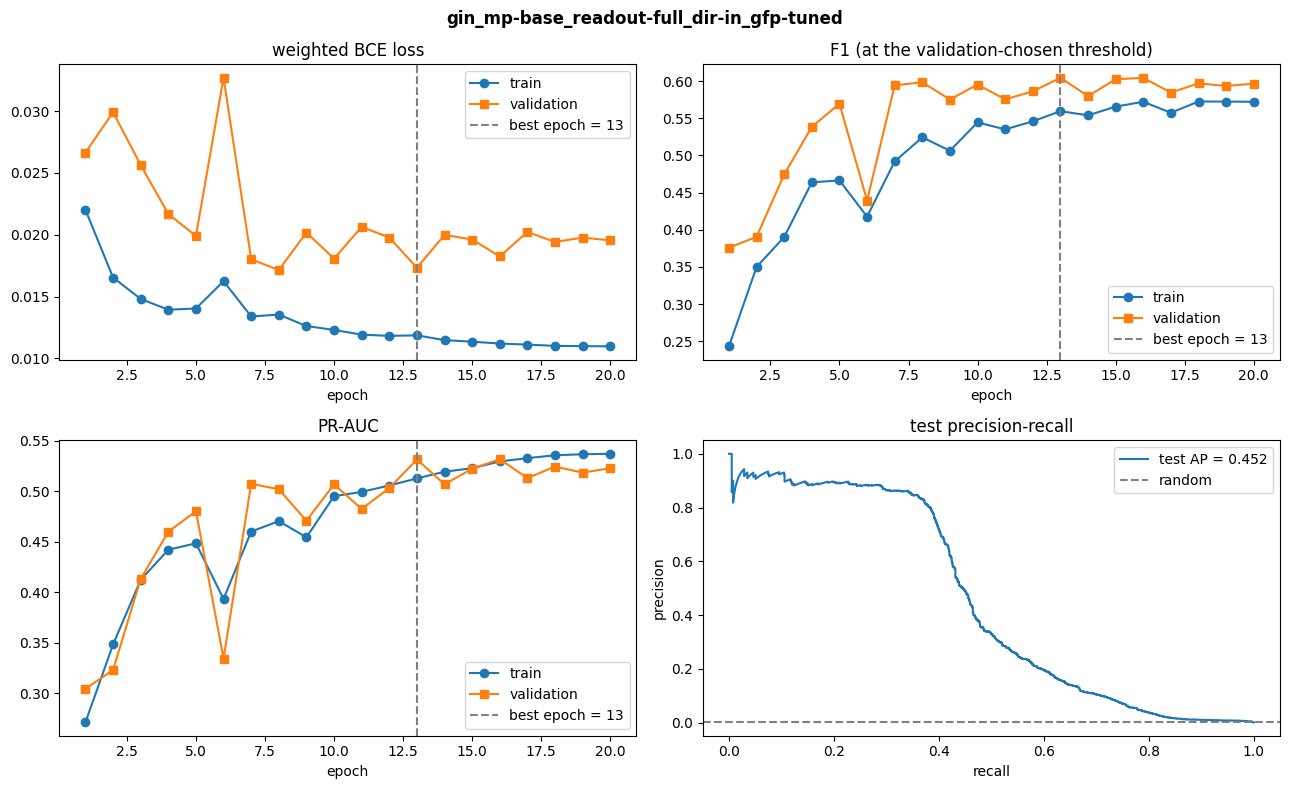

=== gin_mp-full_readout-full_dir-in_gfp-tuned ===
MP edge features: 84 | readout edge features: 84 | node features: 6
total params: 132,995 | architecture-invariant: 67,587


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0092 / 0.0265 | F1 0.6104 / 0.5424 @ 0.673 | PR-AUC 0.6054 / 0.4714 | 132s | RAM 11.7GB   (train / val)
best validation F1 0.5937 at epoch 10 (threshold 0.533)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5505  0.5937  0.4945
precision          0.6580  0.8243  0.7378
recall             0.4732  0.4640  0.3718
pr_auc             0.5361  0.5290  0.4536
roc_auc            0.9898  0.9789  0.9709
precision_at_5pct  0.0138  0.0179  0.0183
recall_at_5pct     0.9125  0.8383  0.8110
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/GIN/gin_mp-full_readout-full_dir-in_gfp-tuned/predictions.csv


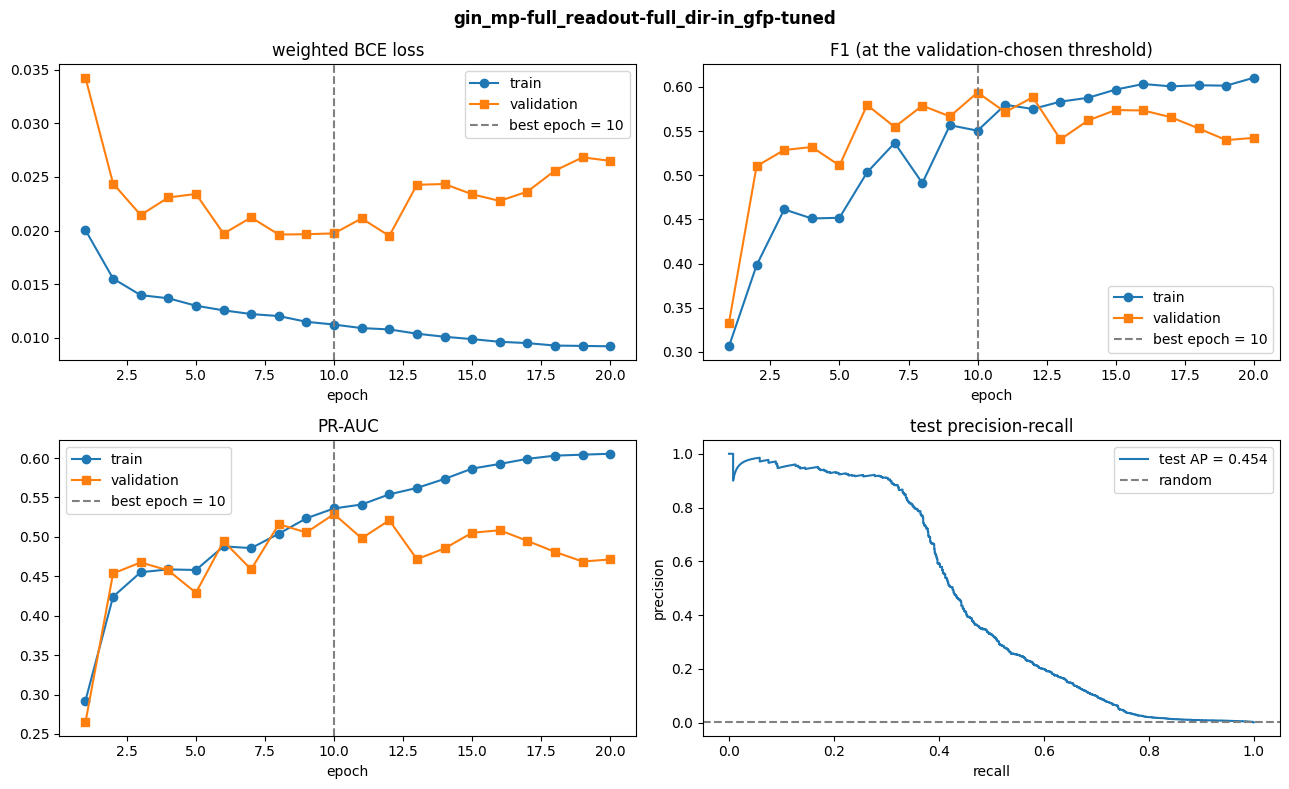

=== gat_mp-base_readout-full_dir-in_gfp-tuned ===
MP edge features: 20 | readout edge features: 84 | node features: 6
total params: 116,353 | architecture-invariant: 67,585


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0135 / 0.0183 | F1 0.4836 / 0.5902 @ 0.575 | PR-AUC 0.4417 / 0.5321 | 88s | RAM 8.9GB   (train / val)
best validation F1 0.5923 at epoch 16 (threshold 0.492)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4573  0.5923  0.5165
precision          0.5055  0.8048  0.6751
recall             0.4175  0.4686  0.4182
pr_auc             0.4386  0.5346  0.4752
roc_auc            0.9855  0.9848  0.9808
precision_at_5pct  0.0134  0.0189  0.0194
recall_at_5pct     0.8868  0.8854  0.8626
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/GAT/gat_mp-base_readout-full_dir-in_gfp-tuned/predictions.csv


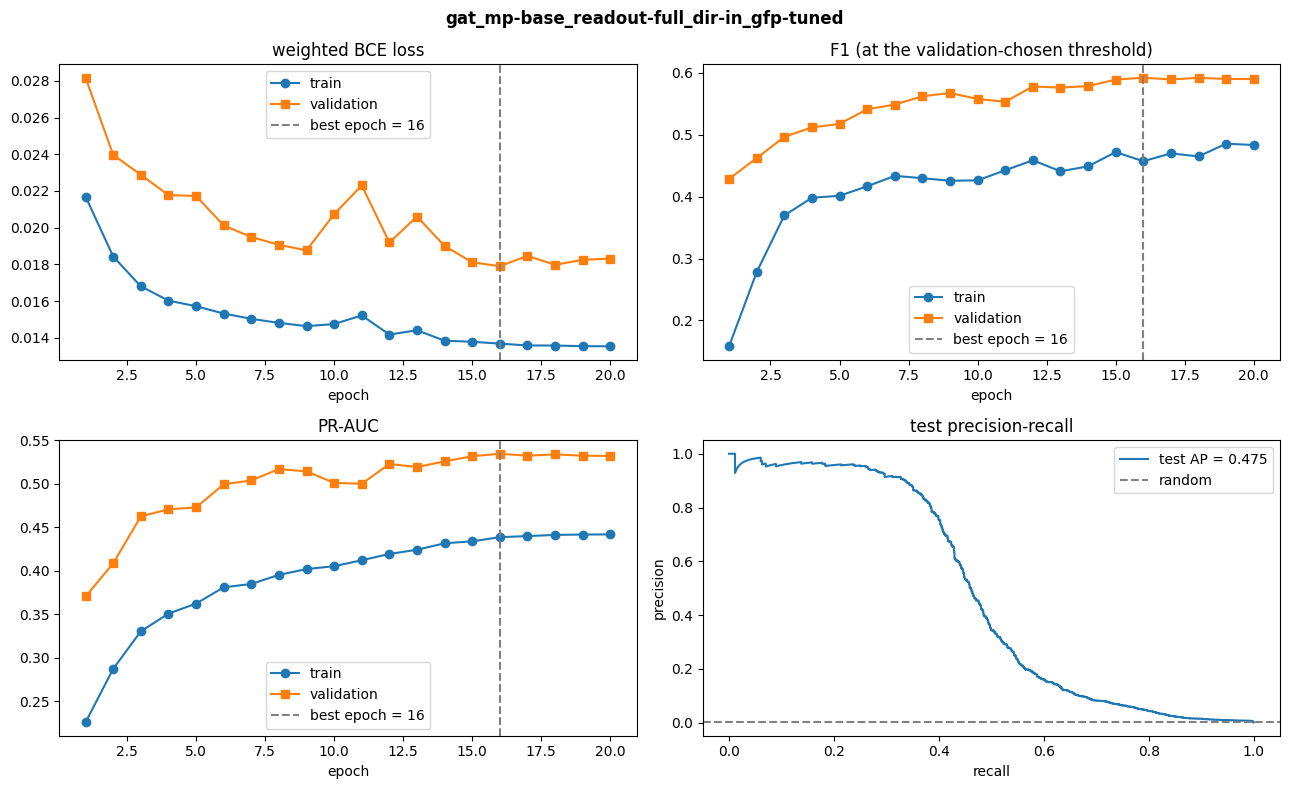

=== gat_mp-full_readout-full_dir-in_gfp-tuned ===
MP edge features: 84 | readout edge features: 84 | node features: 6
total params: 132,737 | architecture-invariant: 67,585


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0127 / 0.0190 | F1 0.5061 / 0.5806 @ 0.541 | PR-AUC 0.4734 / 0.5241 | 157s | RAM 11.9GB   (train / val)
best validation F1 0.5880 at epoch 14 (threshold 0.594)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.4958  0.5871  0.5222
precision          0.5877  0.8283  0.7288
recall             0.4288  0.4547  0.4068
pr_auc             0.4604  0.5298  0.4768
roc_auc            0.9868  0.9838  0.9800
precision_at_5pct  0.0135  0.0188  0.0191
recall_at_5pct     0.8933  0.8817  0.8469
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/GAT/gat_mp-full_readout-full_dir-in_gfp-tuned/predictions.csv


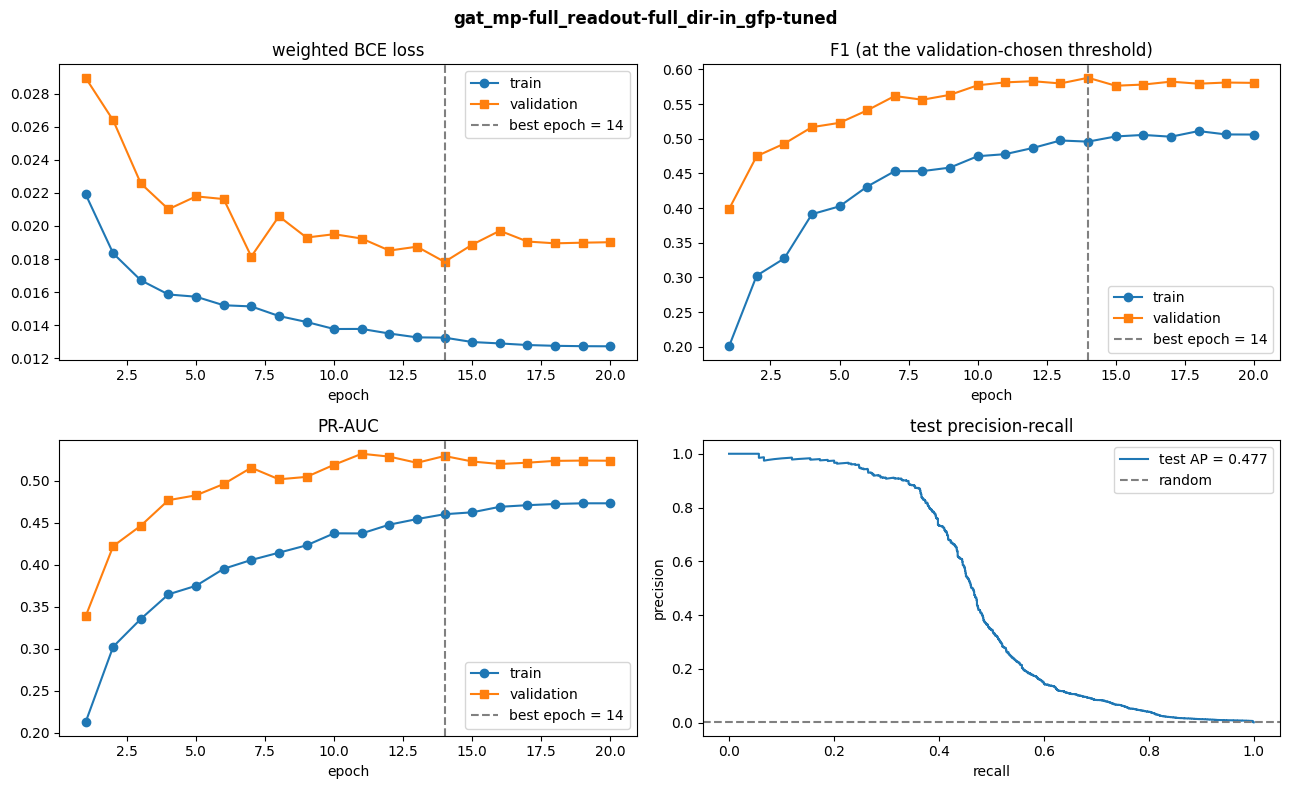

=== pna_mp-base_readout-full_dir-in_gfp-tuned ===
MP edge features: 20 | readout edge features: 84 | node features: 6
total params: 607,873 | architecture-invariant: 427,265


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0100 / 0.0165 | F1 0.6029 / 0.6370 @ 0.685 | PR-AUC 0.5825 / 0.5962 | 195s | RAM 9.0GB   (train / val)
best validation F1 0.6537 at epoch 12 (threshold 0.561)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5644  0.6530  0.6134
precision          0.7059  0.8178  0.7754
recall             0.4702  0.5434  0.5074
pr_auc             0.5453  0.6047  0.5651
roc_auc            0.9902  0.9853  0.9852
precision_at_5pct  0.0139  0.0186  0.0201
recall_at_5pct     0.9199  0.8715  0.8915
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/PNA/pna_mp-base_readout-full_dir-in_gfp-tuned/predictions.csv


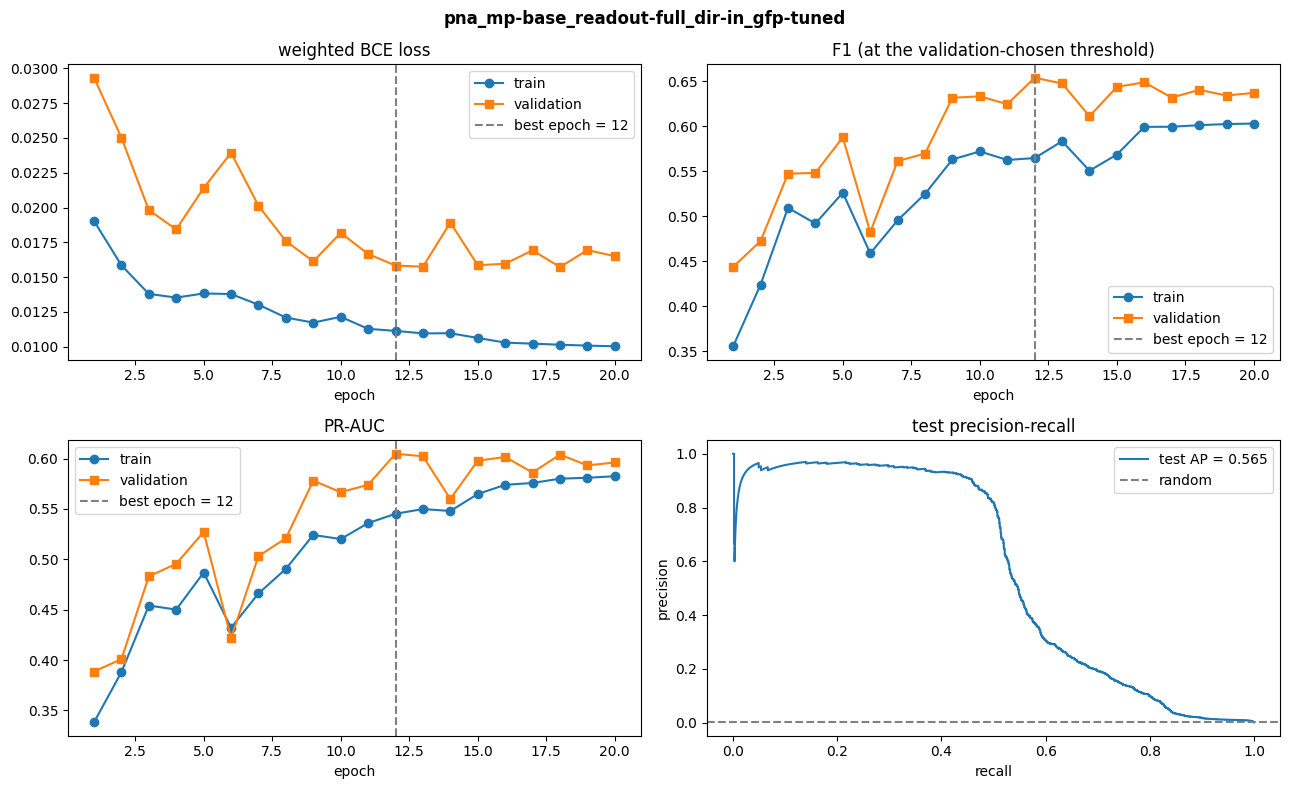

=== pna_mp-full_readout-full_dir-in_gfp-tuned ===
MP edge features: 84 | readout edge features: 84 | node features: 6
total params: 624,257 | architecture-invariant: 427,265


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0090 / 0.0198 | F1 0.6107 / 0.6170 @ 0.723 | PR-AUC 0.6142 / 0.5699 | 241s | RAM 11.9GB   (train / val)
best validation F1 0.6456 at epoch 10 (threshold 0.583)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5636  0.6456  0.6001
precision          0.7304  0.8528  0.8444
recall             0.4589  0.5194  0.4654
pr_auc             0.5338  0.5929  0.5609
roc_auc            0.9891  0.9859  0.9846
precision_at_5pct  0.0137  0.0188  0.0201
recall_at_5pct     0.9068  0.8799  0.8924
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/PNA/pna_mp-full_readout-full_dir-in_gfp-tuned/predictions.csv


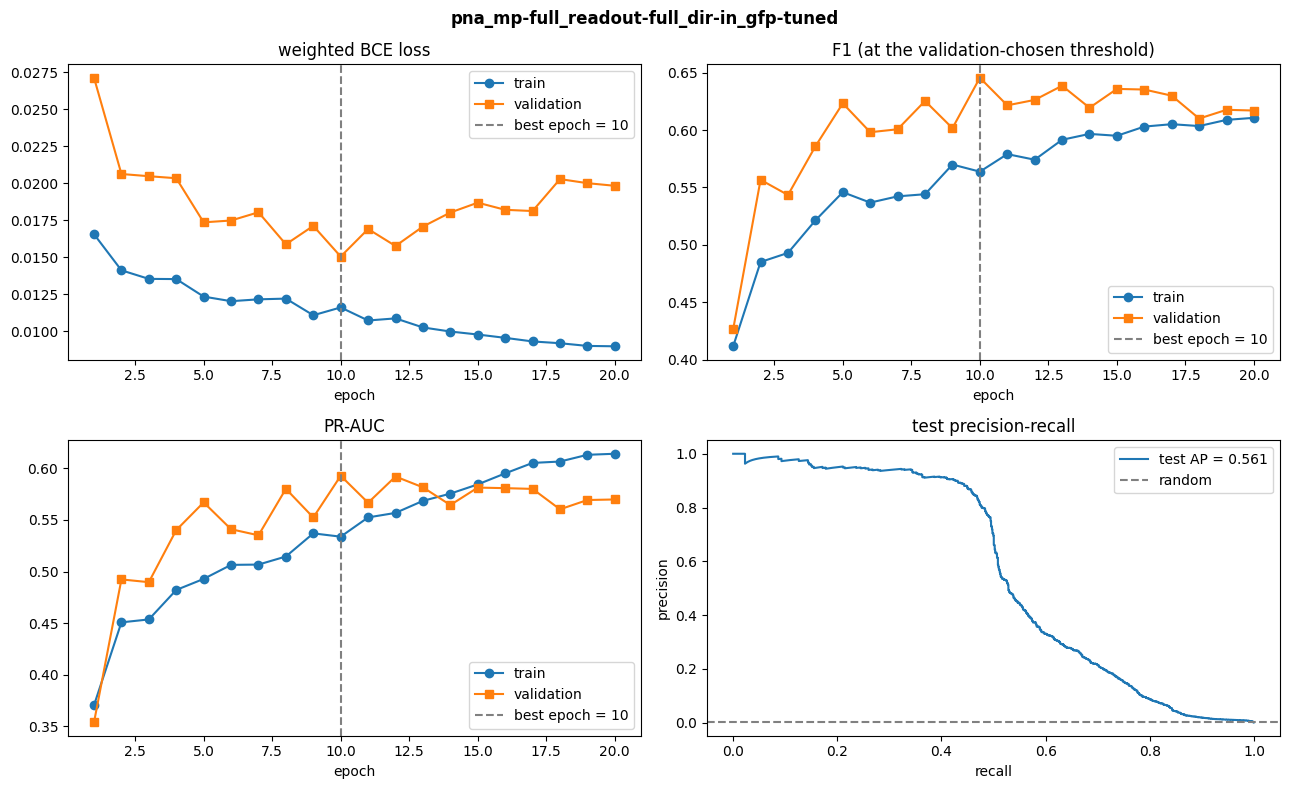

=== transformer_mp-base_readout-full_dir-in_gfp-tuned ===
MP edge features: 20 | readout edge features: 84 | node features: 6
total params: 181,889 | architecture-invariant: 133,121


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0107 / 0.0164 | F1 0.5855 / 0.6312 @ 0.693 | PR-AUC 0.5628 / 0.5862 | 87s | RAM 9.0GB   (train / val)
best validation F1 0.6389 at epoch 15 (threshold 0.637)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5774  0.6389  0.6074
precision          0.7759  0.8545  0.7989
recall             0.4597  0.5102  0.4899
pr_auc             0.5541  0.5918  0.5741
roc_auc            0.9903  0.9850  0.9856
precision_at_5pct  0.0138  0.0187  0.0200
recall_at_5pct     0.9182  0.8762  0.8863
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/TRANSFORMER/transformer_mp-base_readout-full_dir-in_gfp-tuned/predictions.csv


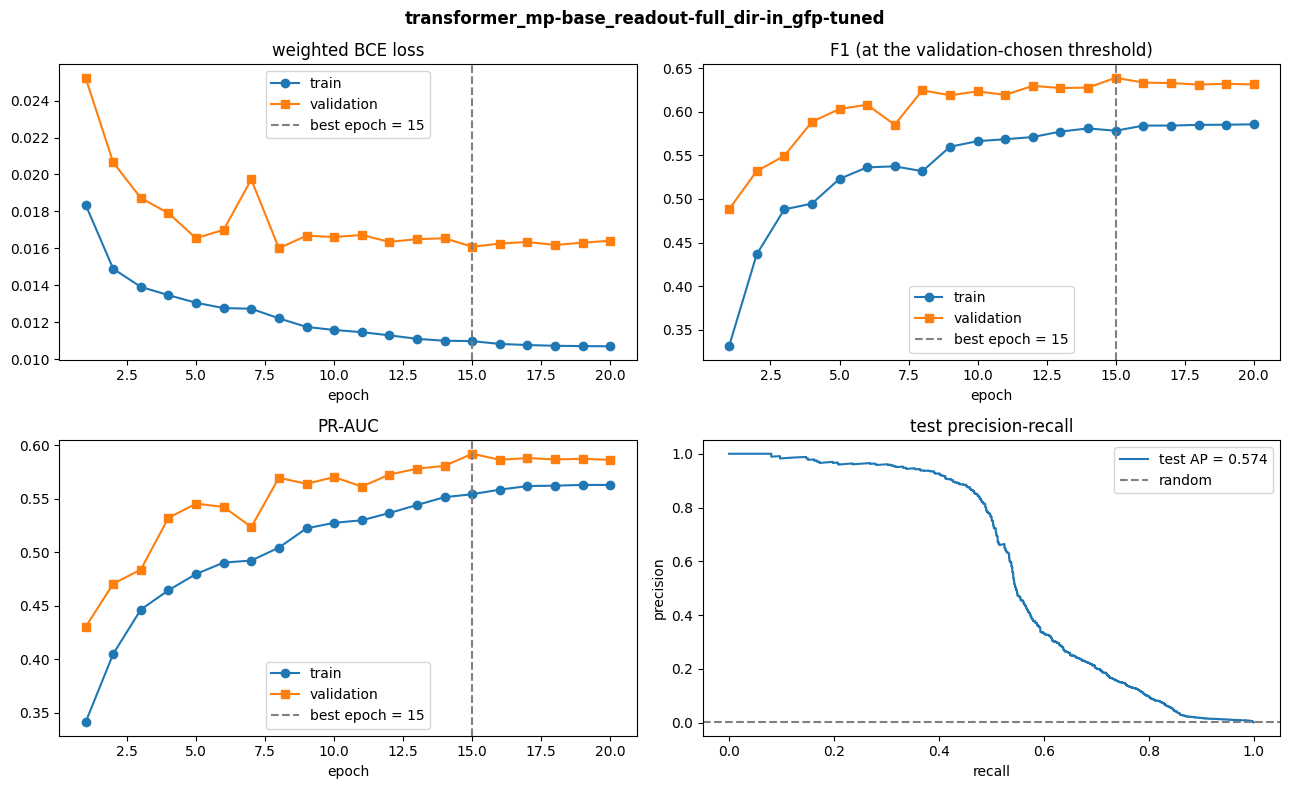

=== transformer_mp-full_readout-full_dir-in_gfp-tuned ===
MP edge features: 84 | readout edge features: 84 | node features: 6
total params: 198,273 | architecture-invariant: 133,121


/usr/local/lib/python3.13/dist-packages/torch_geometric/loader/link_neighbor_loader.py:252: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


train:   0%|          | 0/372 [00:00<?, ?it/s]

predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

...

epoch 20 | loss 0.0097 / 0.0176 | F1 0.6055 / 0.6358 @ 0.704 | PR-AUC 0.6031 / 0.5906 | 144s | RAM 11.9GB   (train / val)
best validation F1 0.6431 at epoch 10 (threshold 0.678)


predict train:   0%|          | 0/372 [00:00<?, ?it/s]

predict val:   0%|          | 0/124 [00:00<?, ?it/s]

predict test:   0%|          | 0/124 [00:00<?, ?it/s]

                    train     val    test
f1                 0.5792  0.6423  0.6044
precision          0.7542  0.8616  0.7957
recall             0.4702  0.5120  0.4873
pr_auc             0.5560  0.5906  0.5636
roc_auc            0.9908  0.9830  0.9822
precision_at_5pct  0.0139  0.0185  0.0195
recall_at_5pct     0.9229  0.8660  0.8653
predictions: 5,077,237 rows -> /kaggle/working/Outputs/GFP_TUNED/TRANSFORMER/transformer_mp-full_readout-full_dir-in_gfp-tuned/predictions.csv


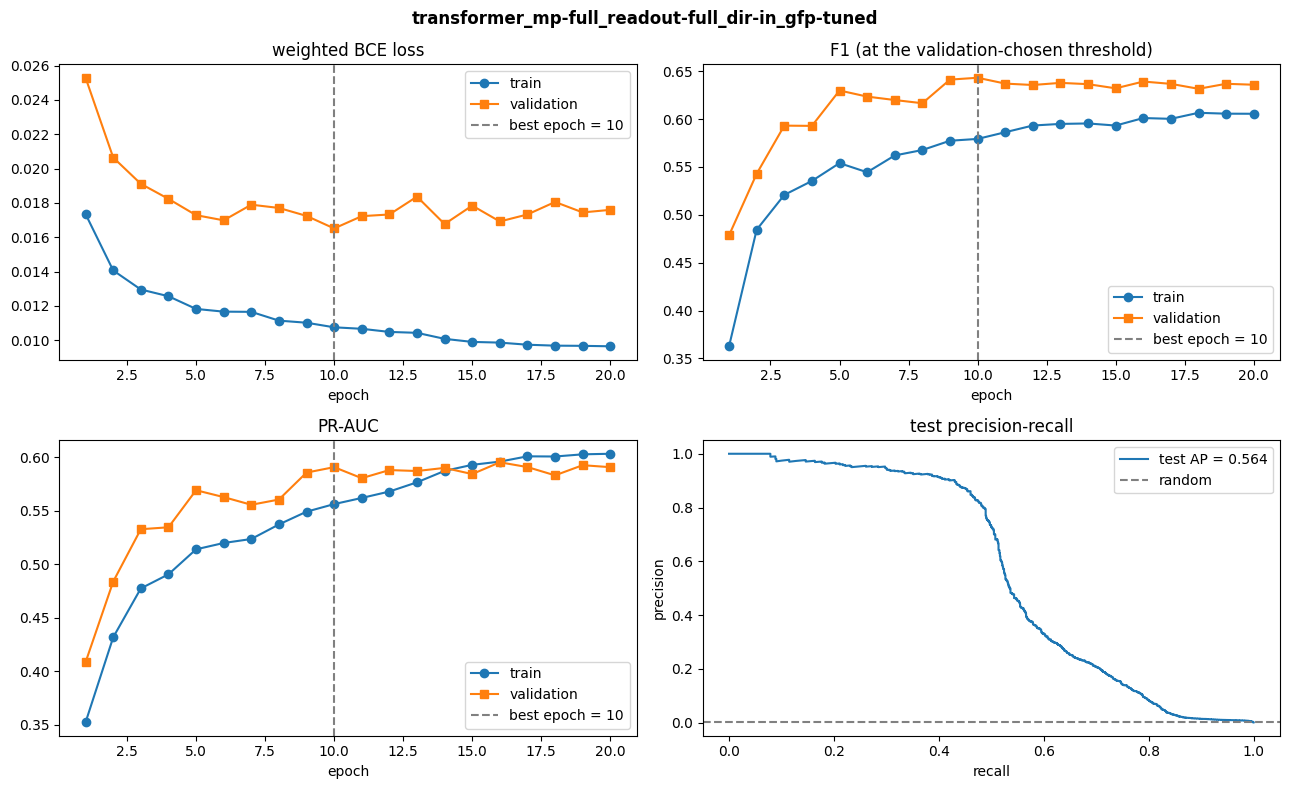

batch complete


In [6]:
rows = []
for cfg in CONFIGS:
    print('=' * 90)
    rows.append(core.run_experiment(cfg['operator'], cfg, graphs, col_sets, node_dim,
                                    f"{OUT_BASE}/{cfg['operator'].upper()}", MP_DIRECTION, TEMPORAL_SAMPLING,
                                    gfp_variant=cfg['gfp_variant']))
print('=' * 90)
print('batch complete')

## 5. Comparison across the batch

- `batch_summary_gfp_tuned.csv` per operator holds every `<split>_<metric>` column plus `threshold`, `best_epoch`, `params`, `invariant_params`, `gfp_variant`.
- `invariant_params` must be identical in every row of an operator (asserted).

In [7]:
for operator in sorted({cfg['operator'] for cfg in CONFIGS}):
    summary = core.summarize_batch([row for row in rows if row['operator'] == operator],
                                   f'{OUT_BASE}/{operator.upper()}', 'batch_summary_gfp_tuned.csv')
    display(summary[['gfp_variant'] + core.DISPLAY_COLS].round(4))

2 runs -> /kaggle/working/Outputs/GFP_TUNED/GAT/batch_summary_gfp_tuned.csv | invariant_params = 67,585 in every row


,gfp_variant,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,tuned,gat_mp-base_readout-full_dir-in_gfp-tuned,16,0.4916,0.5923,0.5165,0.6751,0.4182,0.4752,0.0194,0.8626,116353,67585
1,tuned,gat_mp-full_readout-full_dir-in_gfp-tuned,14,0.5945,0.5871,0.5222,0.7288,0.4068,0.4768,0.0191,0.8469,132737,67585


2 runs -> /kaggle/working/Outputs/GFP_TUNED/GIN/batch_summary_gfp_tuned.csv | invariant_params = 67,587 in every row


,gfp_variant,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,tuned,gin_mp-base_readout-full_dir-in_gfp-tuned,13,0.7219,0.6045,0.5173,0.7572,0.3928,0.4525,0.0188,0.8373,116611,67587
1,tuned,gin_mp-full_readout-full_dir-in_gfp-tuned,10,0.5333,0.5937,0.4945,0.7378,0.3718,0.4536,0.0183,0.8110,132995,67587


2 runs -> /kaggle/working/Outputs/GFP_TUNED/PNA/batch_summary_gfp_tuned.csv | invariant_params = 427,265 in every row


,gfp_variant,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,tuned,pna_mp-base_readout-full_dir-in_gfp-tuned,12,0.5609,0.6530,0.6134,0.7754,0.5074,0.5651,0.0201,0.8915,607873,427265
1,tuned,pna_mp-full_readout-full_dir-in_gfp-tuned,10,0.5832,0.6456,0.6001,0.8444,0.4654,0.5609,0.0201,0.8924,624257,427265


2 runs -> /kaggle/working/Outputs/GFP_TUNED/TRANSFORMER/batch_summary_gfp_tuned.csv | invariant_params = 133,121 in every row


,gfp_variant,run,best_epoch,threshold,val_f1,test_f1,test_precision,test_recall,test_pr_auc,test_precision_at_5pct,test_recall_at_5pct,params,invariant_params
0,tuned,transformer_mp-base_readout-full_dir-in_gfp-tuned,15,0.6375,0.6389,0.6074,0.7989,0.4899,0.5741,0.0200,0.8863,181889,133121
1,tuned,transformer_mp-full_readout-full_dir-in_gfp-tuned,10,0.6778,0.6423,0.6044,0.7957,0.4873,0.5636,0.0195,0.8653,198273,133121


## 6. Download

- Zip `OUT_BASE`; extract into `Outputs/GFP_TUNED/` in the repo and commit the small result files (`best.pt` and `predictions.csv` stay out of git).

In [8]:
import shutil
shutil.make_archive('/kaggle/working/Outputs_GFP_TUNED', 'zip', OUT_BASE)

'/kaggle/working/Outputs_GFP_TUNED.zip'